# Book Recommendation

Every book reader probably knows this problem: What do i read next? In this notebook i will build a recommendation system to recommend books using three different approaches. For this we will use the [Book Recommendation Dataset](https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset/data)

## Content

- [Load and Check Data](#load-and-check-data)
- [Popularity Based Recommendation](#popularity-based-recommendation)
- [Collaborative Filtering](#collaborative-filtering)
- [User Based Recommendation](#user-based-recommendation)
- [Item based filtering](#item-based-filtering)

## Load and Check Data

In [208]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.metrics.pairwise import cosine_similarity

In [209]:
books_df=pd.read_csv('./../Datasets/bookRecommendationDataset/Books.csv')
users_df = pd.read_csv('./../Datasets/bookRecommendationDataset/Users.csv')
ratings_df = pd.read_csv('./../Datasets/bookRecommendationDataset/Ratings.csv')

C:\Users\kyild\AppData\Local\Temp\ipykernel_3984\810213482.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books_df=pd.read_csv('./../Datasets/bookRecommendationDataset/Books.csv')


In [210]:
books_df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [211]:
users_df.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [212]:
ratings_df.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [213]:
books_df=pd.merge(books_df,ratings_df,how='inner',on='ISBN')
books_df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,User-ID,Book-Rating
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,2,0
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,8,5
2,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,11400,0
3,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,11676,8
4,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,41385,0


<Axes: >

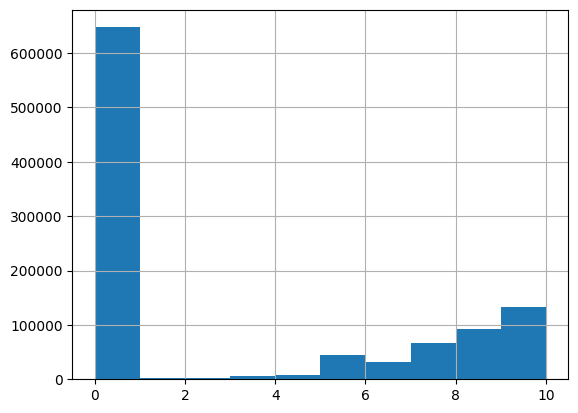

In [214]:
#distribution of book ratings
books_df['Book-Rating'].hist()

In [215]:
books_df.isnull().sum()
books_df.dropna(inplace=True)

## Popularity based Recommendation

The most basics recommendation system is recommending the most popular books to the user, since these are popular for a reason.

In [216]:
books_df.groupby("Book-Title")["Book-Rating"].mean().sort_values(ascending=False).head()

Book-Title
'Isms: a dictionary of words ending in -ism, -ology, and -phobia,: With some similar terms, arranged in subject order    10.0
Ã?Â?berallnie. AusgewÃ?Â¤hlte Gedichte 1928 - 1965.                                                                      10.0
Herb's Pajamas                                                                                                           10.0
Herb, the Vegetarian Dragon (Barefoot Books)                                                                             10.0
Charles Darwin's Letters: A Selection, 1825-1859                                                                         10.0
Name: Book-Rating, dtype: float64

Well these answers don't make much sense since i have never heard of these books before. Most likely these books have low rating count but high ratings. To avoid this I will determine the popular books.

In [217]:
rating_count=books_df.groupby("Book-Title").count()["Book-Rating"].reset_index()
rating_count.rename(columns={"Book-Rating":"VotingCount"},inplace=True)
rating_average=books_df.groupby("Book-Title")["Book-Rating"].mean().reset_index()
rating_average.rename(columns={"Book-Rating":"AverageRating"},inplace=True)
popular_books_df=rating_count.merge(rating_average,on='Book-Title')
C=popular_books_df["AverageRating"].mean()
m=popular_books_df["VotingCount"].quantile(0.90)
def weighted_rate(x):
    v=x["VotingCount"]
    R=x["AverageRating"]
    
    return ((v*R) + (m*C)) / (v+m)
popular_books_df=popular_books_df[popular_books_df["VotingCount"]>=250]
popular_books_df["Popularity"] = popular_books_df.apply(weighted_rate,axis=1)
popular_books_df.sort_values(by="AverageRating",ascending=False).reset_index(drop=True).head(10) # Puts out the 10 most popular books

,Book-Title,VotingCount,AverageRating,Popularity
0,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804,5.805128
1,Harry Potter and the Goblet of Fire (Book 4),387,5.824289,5.772159
2,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410,5.667476
3,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441,5.449804
4,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453,5.154939
5,The Hobbit : The Enchanting Prelude to The Lor...,281,5.007117,4.955662
6,The Fellowship of the Ring (The Lord of the Ri...,368,4.948370,4.909948
7,Harry Potter and the Sorcerer's Stone (Harry P...,575,4.895652,4.871530
8,"The Two Towers (The Lord of the Rings, Part 2)",260,4.880769,4.828579
9,To Kill a Mockingbird,510,4.700000,4.675494


## Collaborative filtering

In [218]:
# Filter out users with less than 200 votes 
rating_counts = books_df['User-ID'].value_counts().sort_values(ascending=True)
user_over_200_votes = rating_counts[rating_counts > 200].index
users_filtered_df = books_df[books_df["User-ID"].isin(user_over_200_votes)]

In [219]:
user_ratings=users_filtered_df.pivot_table(index=["User-ID"],columns=['Book-Title'],values="Book-Rating")

First lets look at the density of the matrix

In [220]:
sparsity=user_ratings.isnull().values.sum() / (user_ratings.size)
sparsity

np.float64(0.9962830132020408)

In [221]:
avg_ratings = user_ratings.mean(axis=1)
user_ratings = user_ratings.sub(avg_ratings,axis=0) # bring the values closer to 0
user_ratings.fillna(0,inplace=True)
user_ratings

Book-Title,"A Light in the Storm: The Civil War Diary of Amelia Martin, Fenwick Island, Delaware, 1861 (Dear America)",Always Have Popsicles,Apple Magic (The Collector's series),Beyond IBM: Leadership Marketing and Finance for the 1990s,Clifford Visita El Hospital (Clifford El Gran Perro Colorado),Dark Justice,Deceived,"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",Final Fantasy Anthology: Official Strategy Guide (Brady Games),Flight of Fancy: American Heiresses (Zebra Ballad Romance),...,Â¿Eres tu mi mamÃ¡?/Are You My Mother?,"Â¿QuÃ© me quieres, amor?","Ã?ber den Wunsch, sich wohlzufÃ¼hlen: Geschichten",Ã?coute ma diffÃ©rence (Le Temps des femmes),Ã?ngeles fugaces (Falling Angels),Ã?Â?ber das Fernsehen.,Ã?Â?ber die Pflicht zum Ungehorsam gegen den Staat.,Ã?Â?lpiraten.,Ã?Â?stlich der Berge.,Ã?Â?thique en toc
User-ID,,,,,,,,,,,,,,,,,,,,,
254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2276,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2766,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2977,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3363,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274308,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
275970,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
277427,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## User Based Recommendation

In the previous step I calculated the cosine similarity matrix of our dataset. Following this it is possible to make recommendation based on the similar users. 

In [222]:
cosine_similarity(user_ratings.T.loc['Harry Potter and the Prisoner of Azkaban (Book 3)',:].values.reshape(1,-1) ,user_ratings.T.loc['Harry Potter and the Sorcerer\'s Stone (Book 1)',:].values.reshape(1,-1) )


array([[0.33018074]])

In [223]:
similarities = cosine_similarity(user_ratings)
cosine_similarity_df=pd.DataFrame(similarities,index=user_ratings.index,columns=user_ratings.index)
cosine_similarity_df = cosine_similarity_df.rename(index=str, columns=str)
cosine_similarity_df.head()

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
User-ID,,,,,,,,,,,,,,,,,,,,,
254,1.000000,-0.003026,-0.007619,0.009729,0.015159,-0.033060,-0.010672,0.012308,-0.002128,0.013961,...,0.009597,-0.018717,-0.001112,0.001767,0.001561,0.020903,0.027782,-0.016107,0.001162,-0.000067
2276,-0.003026,1.000000,0.003725,0.002994,-0.001839,-0.002241,0.003085,0.001336,-0.000996,-0.010456,...,-0.002276,0.003179,0.002929,-0.011990,-0.007317,-0.001352,-0.000495,0.001701,0.014782,-0.000459
2766,-0.007619,0.003725,1.000000,-0.003809,0.004159,0.013397,0.000000,-0.008815,0.018146,-0.004678,...,-0.004341,-0.010422,0.004704,-0.001452,-0.006331,-0.011505,0.002844,0.003427,-0.010546,-0.000706
2977,0.009729,0.002994,-0.003809,1.000000,-0.005037,-0.008868,0.000000,0.012808,-0.010904,-0.009863,...,-0.002153,0.009744,-0.002915,-0.004241,0.009636,0.000810,-0.005403,0.001648,-0.006061,0.000431
3363,0.015159,-0.001839,0.004159,-0.005037,1.000000,0.017194,-0.001015,-0.000808,-0.005015,0.000748,...,0.005786,-0.005307,-0.000995,0.001084,-0.000156,-0.005676,-0.004184,-0.003184,-0.004050,-0.001563


In [230]:
def get_favorite_books(id):
    # extract the favorite books from user
    return books_df.loc[books_df["User-ID"]==int(id)].sort_values(by="Book-Rating",ascending=False)[0:10]

def recommend_users(target):
    # get the list of similar users to target
    list_of_similar_users=cosine_similarity_df.loc[str(target)].sort_values(ascending=False)[1:6]
    return list_of_similar_users

def recommendation_user_based(target):
    # give out a list of books recommended for the target based on similar users
    list_of_users=recommend_users(target)
    fav_of_target = get_favorite_books(target)
    df = pd.DataFrame()
    for x in list_of_users.index:
        df = pd.concat([df,get_favorite_books(x)],axis=0)
    df.drop_duplicates(subset=["ISBN","Book-Title"],inplace=True)
    df
    recommended_list=df.loc[(~df["Book-Title"].isin(fav_of_target["Book-Title"]) & (df['Book-Rating']>df['Book-Rating'].mean()))]
    # select random samples from the list
    list = recommended_list.sample(n=10)["Book-Title"].values.tolist()
    print(f"User {target} could also like :\n{'\n'.join(list)}:")

recommendation_user_based(31556)

User 31556 could also like :
Harry Potter and the Prisoner of Azkaban (Book 3)
Lord of the Flies
Nickel and Dimed: On (Not) Getting By in America
The Fellowship of the Ring (The Lord of the Rings, Part 1)
Into Thin Air : A Personal Account of the Mt. Everest Disaster
Angels &amp; Demons
The Fellowship of the Ring (The Lord of the Rings, Part 1)
Harry Potter and the Goblet of Fire (Book 4)
Harry Potter and the Chamber of Secrets (Book 2)
The Da Vinci Code:


## Item Based Filtering

After doing recommendations based on user similarities its time to use singular books for recommending. 

In [225]:
books_df = books_df[books_df["Book-Title"].isin(popular_books_df["Book-Title"].values)]
books_df.size

746730

In [226]:
book_ratings=books_df.pivot_table(index=["Book-Title"],columns=['User-ID'],values="Book-Rating")
avg_ratings = book_ratings.mean(axis=1)
book_ratings = book_ratings.sub(avg_ratings,axis=0) # bring the values closer to 0
book_ratings.fillna(0,inplace=True)
book_ratings

User-ID,8,9,14,16,26,44,51,67,91,95,...,278769,278773,278781,278796,278798,278800,278813,278836,278843,278844
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-4.459976,0.000000,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
"A Child Called \It\"": One Child's Courage to Survive""",0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
White Oleander : A Novel,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
White Oleander : A Novel (Oprah's Book Club),0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,3.227528,0.0,0.0,0.0,0.0,0.0
Wicked: The Life and Times of the Wicked Witch of the West,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [227]:
similarities = cosine_similarity(book_ratings)
cosine_similarity_books=pd.DataFrame(similarities,index=book_ratings.index,columns=book_ratings.index)
cosine_similarity_books

Book-Title,1984,1st to Die: A Novel,2nd Chance,A Bend in the Road,"A Child Called \It\"": One Child's Courage to Survive""",A Heartbreaking Work of Staggering Genius,A Is for Alibi (Kinsey Millhone Mysteries (Paperback)),A Map of the World,A Painted House,A Prayer for Owen Meany,...,We Were the Mulvaneys,When the Wind Blows,Where the Heart Is (Oprah's Book Club (Paperback)),While I Was Gone,Whispers,White Oleander : A Novel,White Oleander : A Novel (Oprah's Book Club),Wicked: The Life and Times of the Wicked Witch of the West,Wild Animus,"\O\"" Is for Outlaw"""
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,1.000000,0.001390,0.006908,0.005840,0.000337,-0.008345,0.003201,0.012723,0.018112,0.029663,...,0.014544,0.031693,0.002790,-0.001903,0.009097,-0.001954,0.009658,-0.000062,0.014746,-0.001984
1st to Die: A Novel,0.001390,1.000000,0.097605,0.043798,0.028973,0.008231,0.066098,0.048867,0.020053,0.020579,...,0.031184,0.058835,0.030917,0.019931,0.024148,0.016788,0.022544,0.031655,0.010256,0.041834
2nd Chance,0.006908,0.097605,1.000000,0.024601,0.008455,0.010664,0.042016,0.014496,0.037151,0.017284,...,0.013546,0.063010,0.025996,0.037106,0.029087,0.009515,0.018932,-0.009592,0.022643,0.051297
A Bend in the Road,0.005840,0.043798,0.024601,1.000000,0.046168,0.015231,0.034969,0.053560,0.037265,0.036429,...,0.052702,0.032659,0.041210,0.012273,0.046752,0.051117,0.014031,0.025179,0.022932,0.029869
"A Child Called \It\"": One Child's Courage to Survive""",0.000337,0.028973,0.008455,0.046168,1.000000,0.021219,0.040323,0.023542,-0.004286,0.010773,...,0.030843,0.026227,0.040262,0.006905,0.011764,0.034251,0.018210,-0.016207,0.012449,0.003648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
White Oleander : A Novel,-0.001954,0.016788,0.009515,0.051117,0.034251,0.004956,0.024226,0.029835,0.023107,0.041419,...,0.078893,0.025334,0.040307,0.019401,0.011633,1.000000,0.007723,0.024893,0.020474,0.031598
White Oleander : A Novel (Oprah's Book Club),0.009658,0.022544,0.018932,0.014031,0.018210,0.008291,0.006154,0.040713,0.022393,0.012842,...,-0.004401,0.023806,0.001847,-0.002863,0.007645,0.007723,1.000000,0.030489,-0.002171,0.004639
Wicked: The Life and Times of the Wicked Witch of the West,-0.000062,0.031655,-0.009592,0.025179,-0.016207,0.029098,0.031828,0.057529,0.026245,0.036938,...,0.044083,0.007387,0.008201,0.024883,0.010199,0.024893,0.030489,1.000000,0.008184,0.000213


In [228]:
def book_based_recommendation(book_title):

    rec_books = cosine_similarity_books.loc[book_title].sort_values(ascending=False)[1:6].index
    print(f"Based on {book_title} u could also like :\n{'\n'.join(rec_books)}:")
    return 

book_based_recommendation('The Two Towers (The Lord of the Rings, Part 2)')

Based on The Two Towers (The Lord of the Rings, Part 2) u could also like :
The Fellowship of the Ring (The Lord of the Rings, Part 1)
The Hobbit : The Enchanting Prelude to The Lord of the Rings
Congo
The Vampire Lestat (Vampire Chronicles, Book II)
Dreamcatcher:
